
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [22]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions. 

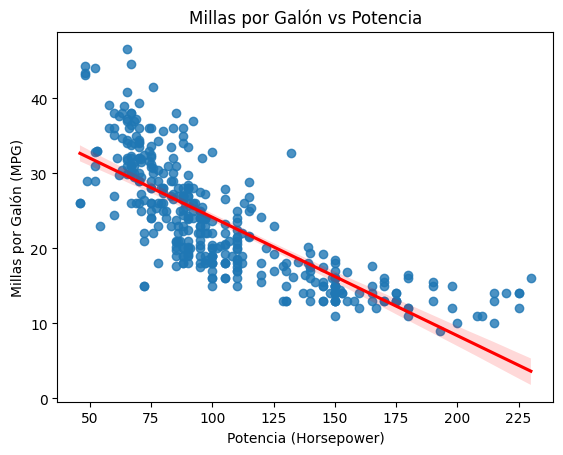

In [23]:
df = pd.read_csv('millas_por_galon.csv')

sns.regplot(
    data=df,
    x='horsepower',
    y='mpg',
    ci=95,
    line_kws={'color': 'red'}
)

plt.title('Millas por Galón vs Potencia')
plt.xlabel('Potencia (Horsepower)')
plt.ylabel('Millas por Galón (MPG)')
plt.show()

De los datos se observa que hay una mayor concentración de vehículos que recorren más millas por galón pero con una menor potencia, como es de esperarse dado que los vehículos de mayor potencia consumen mucho más combustible.

AJUTSE LINEAL MUY REGULAR... MEJORAR EL AJUSTE LINEAL CON UNA CURVA POLINOMIAL DE GRADO 2 O 3.

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$ 
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

In [24]:
url='https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv'
df=pd.read_csv(url)

df=df[['vS','YRC','MDF','mChi1','Omega']]

def Mn(row):
    return row['YRC']*row['vS'] / np.sqrt(2)

df['MN']=df.apply(Mn,axis=1)

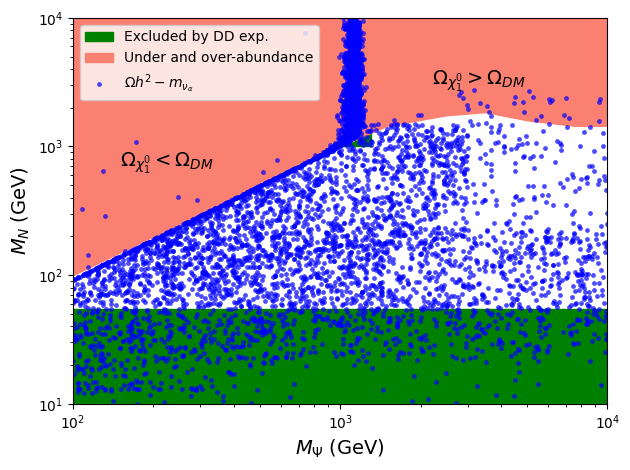

In [ ]:
fig, ax=plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2,1e4)
ax.set_ylim(1e1,1e4)

x_all=np.logspace(2,4,500)
ax.fill_between(x_all, 1e1, 5.5e1, color="green", alpha=1.0, label="Excluded by DD exp.")
ax.fill_between([1000,1300], [1000,1000], [1e4,1e4], color="green", alpha=1.0)

x_left = np.logspace(2,3,500)
ax.fill_between(x_left, x_left, 1e4, color="salmon", alpha=1.0, label="Under and over-abundance")

log_x_pts=np.log10([1000, 1500, 2500, 3500, 5000, 7500, 10000])
log_y_pts=np.log10([1000, 1450, 1750, 1850, 1600, 1450, 1450])
interp_func=interp1d(log_x_pts, log_y_pts, kind='linear')

x_right=np.logspace(3, 4, 300)
y_right=10**interp_func(np.log10(x_right))
ax.fill_between(x_right, y_right, 1e4, color="salmon", alpha=1.0)

sns.scatterplot(data=df, x="MDF", y="MN", color="blue", s=12, alpha=0.7, 
                linewidth=0, ax=ax, label=r"$\Omega h^2 - m_{\nu_\alpha}$")

ax.text(1.5e2, 7e2, r"$\Omega_{\chi_1^0} < \Omega_{DM}$", fontsize=14, weight='bold')
ax.text(2.2e3, 3e3, r"$\Omega_{\chi_1^0} > \Omega_{DM}$", fontsize=14, weight='bold')
ax.set_xlabel(r"$M_{\Psi}\;(\mathrm{GeV})$", fontsize=14)
ax.set_ylabel(r"$M_N\;(\mathrm{GeV})$", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

#no supe cómo hacer bien la delimitación de la zonas salmón

USAR FILLBETWEEN BIEN,,, PERO REALMENTE NO HACE LOS CORTES EN PANDAS...
NOTA 2.3+2